# Gradient Descent and Optimization

This notebook explores gradient descent and optimization techniques, building upon the numerical differentiation concepts from the previous notebook. These techniques form the foundation of training algorithms in neural networks and machine learning.

## Learning Objectives
- Understand the concept of optimization and gradient descent
- Implement gradient descent from scratch
- Explore different variants of gradient descent
- Visualize optimization algorithms in action
- Apply optimization to function fitting problems

## 1. Introduction to Optimization

In many mathematical and machine learning problems, we need to find the minimum (or maximum) of a function. For example, in machine learning, we typically want to minimize a loss function.

Optimization algorithms allow us to systematically search for these optima. One of the most fundamental optimization techniques is gradient descent, which uses the gradient (derivative) of a function to iteratively improve our solution.

Let's start by importing the necessary libraries:

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sys
import os
from mpl_toolkits.mplot3d import Axes3D

# Add the parent directory to the path to import our modules
module_path = os.path.abspath(os.path.join('..'))
if module_path not in sys.path:
    sys.path.append(module_path)

from phase0.calculus.differentiation import gradient
from phase0.calculus.optimization import (
    gradient_descent,
    gradient_descent_with_momentum,
    adagrad,
    rmsprop,
    adam
)
from phase0.calculus.utils import (
    plot_function_1d,
    plot_function_2d,
    plot_gradient_descent_1d, 
    plot_contour_with_path,
    plot_optimizer_comparison
)

## 2. Basic Gradient Descent

Gradient descent is an iterative optimization algorithm that works by following the negative gradient of a function to reach its minimum. The basic update rule is:

$$x_{t+1} = x_t - \alpha \nabla f(x_t)$$

where:
- $x_t$ is the current position
- $\alpha$ is the learning rate (step size)
- $\nabla f(x_t)$ is the gradient of function $f$ at position $x_t$

Let's implement and visualize gradient descent on a simple 1D function.

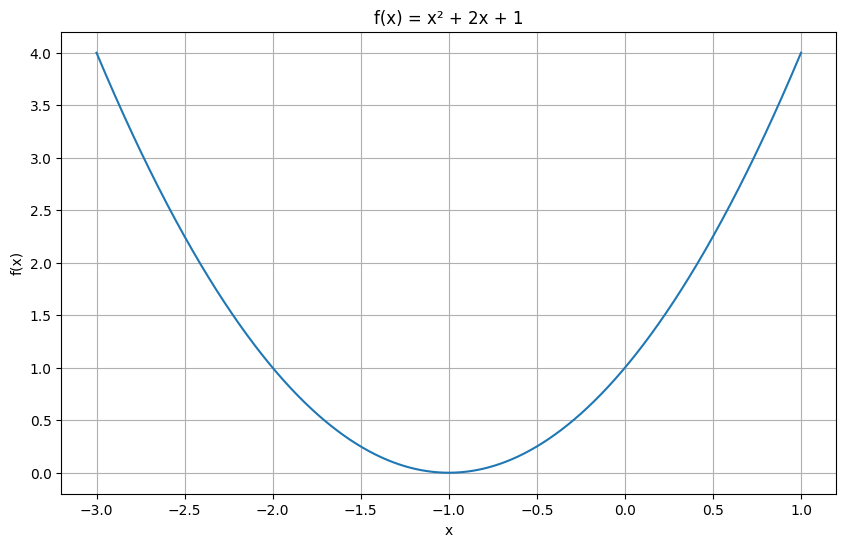

In [2]:
# Define a simple 1D function with a minimum
def f1(x):
    return x**2 + 2*x + 1  # This is (x+1)^2, so minimum is at x=-1

# Analytical gradient of f1
def df1(x):
    return 2*x + 2

# Visualize the function
plot_function_1d(f1, -3, 1, title="f(x) = x² + 2x + 1")

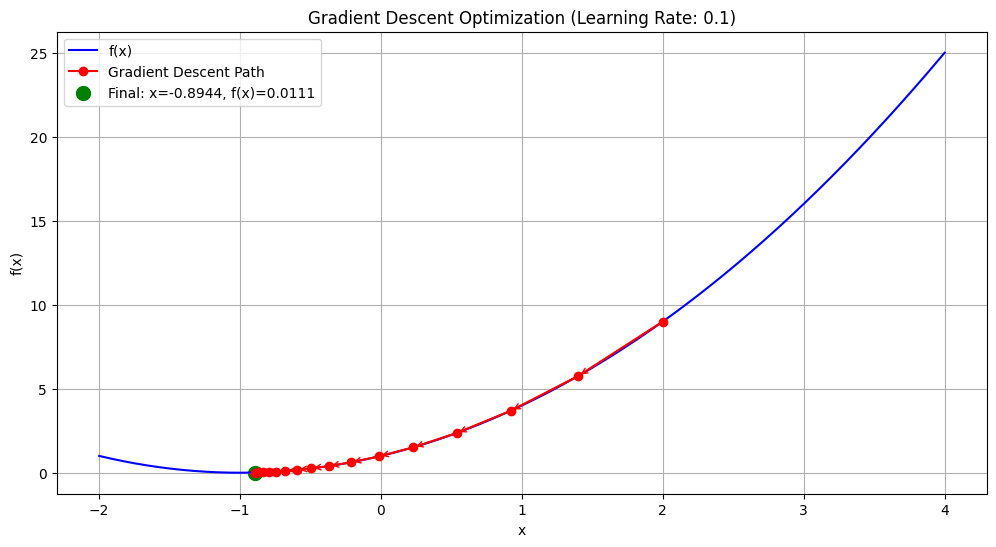

In [3]:
# Visualize gradient descent on this function
plot_gradient_descent_1d(f1, df1, x0=2.0, learning_rate=0.1, max_iter=15)

Let's see how the learning rate affects convergence:

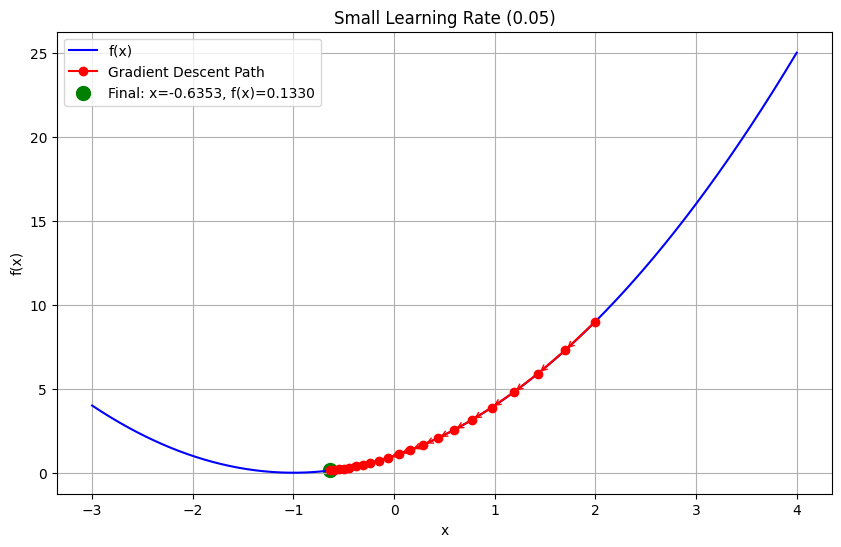

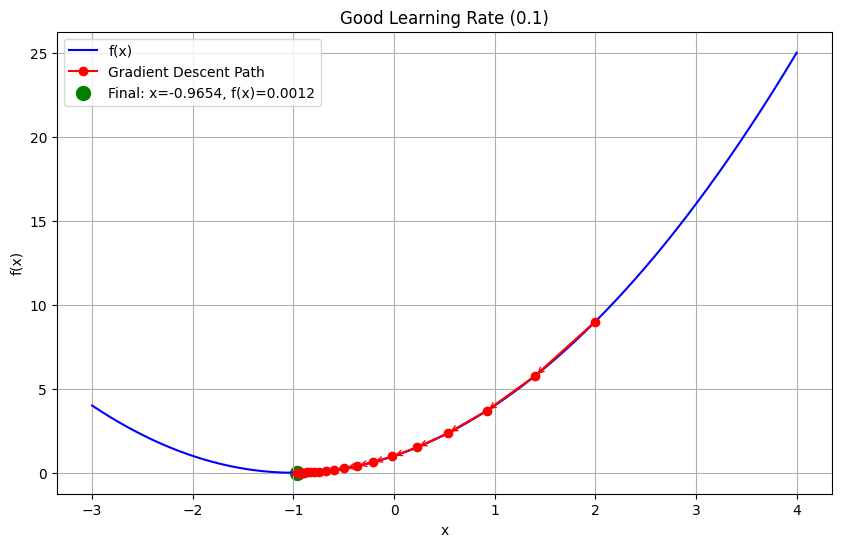

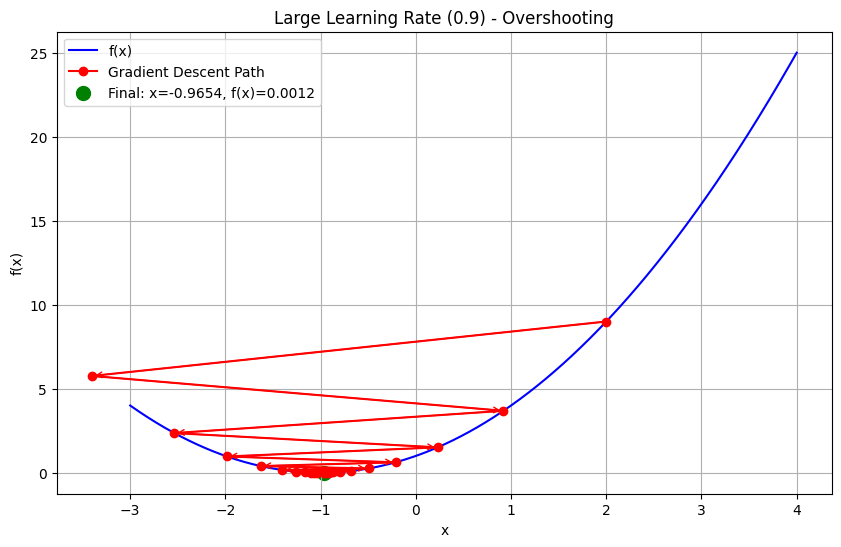

In [4]:
# Create a helper function to create individual figures for different learning rates
def show_gradient_descent_with_rate(f, df, x0, learning_rate, max_iter, title):
    # Find reasonable plot range
    x_min = min(x0 - 2, -3)
    x_max = max(x0 + 2, 3)
    
    # Generate points for function plot
    x = np.linspace(x_min, x_max, 1000)
    y = np.array([f(xi) for xi in x])
    
    # Run gradient descent
    x_history = [x0]
    for i in range(max_iter):
        grad = df(x_history[-1])
        x_new = x_history[-1] - learning_rate * grad
        x_history.append(x_new)
    
    # Convert to numpy array for easier indexing
    x_history = np.array(x_history)
    y_history = np.array([f(xi) for xi in x_history])
    
    # Create new figure
    plt.figure(figsize=(10, 6))
    
    # Create plot
    plt.plot(x, y, 'b-', label='f(x)')
    plt.plot(x_history, y_history, 'ro-', label='Gradient Descent Path')
    
    # Add arrows to show direction
    for i in range(len(x_history) - 1):
        plt.annotate("", xy=(x_history[i+1], y_history[i+1]), 
                    xytext=(x_history[i], y_history[i]),
                    arrowprops=dict(arrowstyle="->", color="red"))
    
    plt.scatter(x_history[-1], y_history[-1], color='g', s=100, 
               label=f'Final: x={x_history[-1]:.4f}, f(x)={y_history[-1]:.4f}')
    
    plt.title(title)
    plt.xlabel('x')
    plt.ylabel('f(x)')
    plt.legend()
    plt.grid(True)
    plt.show()

# Try different learning rates in separate figures
show_gradient_descent_with_rate(f1, df1, x0=2.0, learning_rate=0.05, max_iter=20, 
                               title="Small Learning Rate (0.05)")
show_gradient_descent_with_rate(f1, df1, x0=2.0, learning_rate=0.1, max_iter=20, 
                               title="Good Learning Rate (0.1)")
show_gradient_descent_with_rate(f1, df1, x0=2.0, learning_rate=0.9, max_iter=20, 
                               title="Large Learning Rate (0.9) - Overshooting")

**Observations:**

- With a small learning rate, gradient descent converges slowly but steadily
- With a good learning rate, it converges efficiently
- With a too large learning rate, it can overshoot and oscillate or even diverge

The choice of learning rate is critical for the performance of gradient descent.

## 3. Gradient Descent in Higher Dimensions

Let's extend our exploration to functions with multiple variables. In higher dimensions, we use partial derivatives to compute the gradient vector.

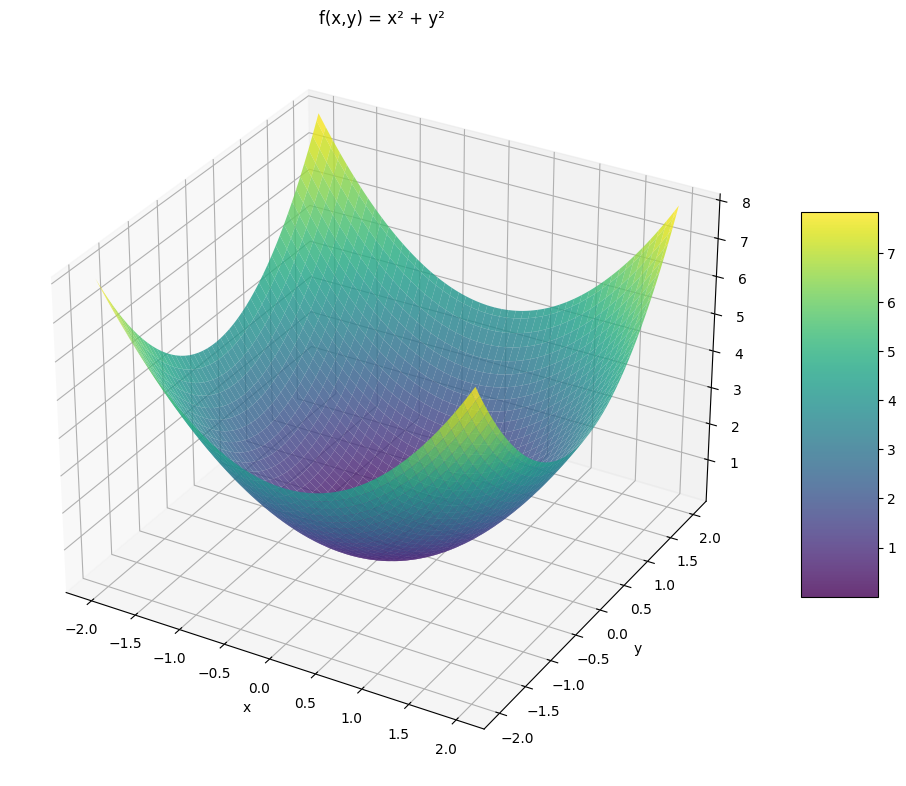

In [5]:
# Define a 2D function (bowl-shaped)
def bowl_function(x):
    return x[0]**2 + x[1]**2

# Gradient of the bowl function
def bowl_gradient(x):
    return np.array([2*x[0], 2*x[1]])

# Visualize the function
plot_function_2d(bowl_function, -2, 2, -2, 2, plot_type='surface', title="f(x,y) = x² + y²")

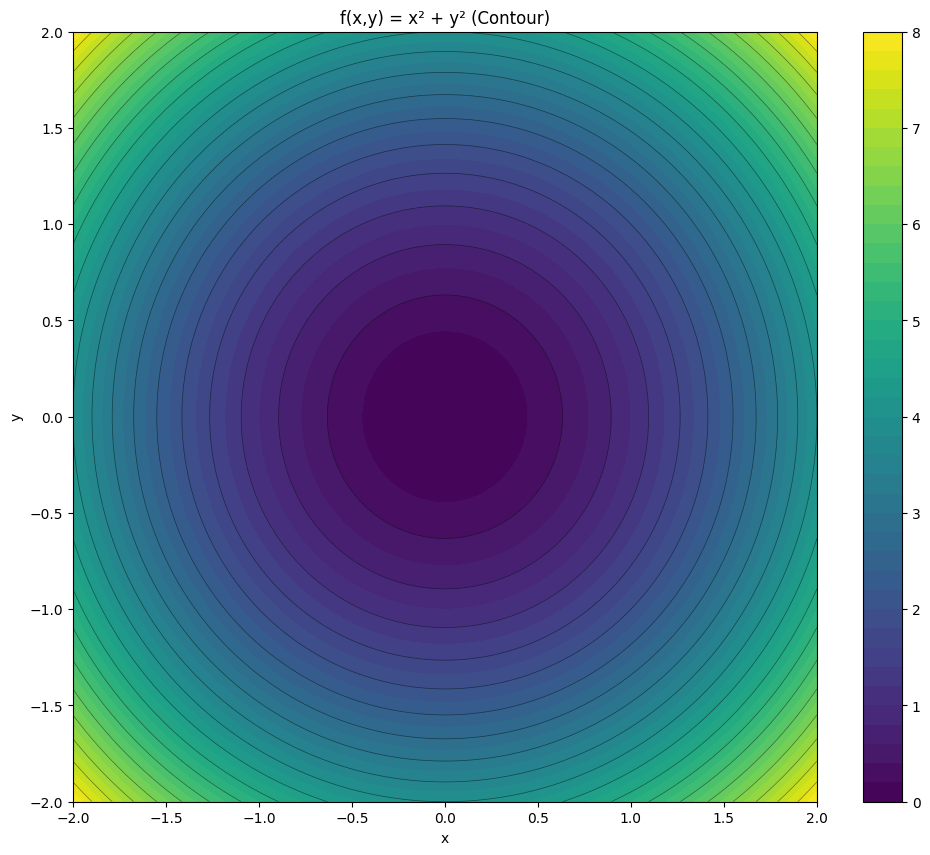

In [6]:
# Let's also look at the contour plot
plot_function_2d(bowl_function, -2, 2, -2, 2, plot_type='contour', title="f(x,y) = x² + y² (Contour)")

In [7]:
# Run gradient descent on the 2D function
x0 = np.array([1.5, 1.5])  # Starting point
result, history = gradient_descent(bowl_function, bowl_gradient, x0, learning_rate=0.1, max_iter=20)

print("Starting point:", x0)
print("Result after optimization:", result)
print("Function value at result:", bowl_function(result))
print("Number of iterations:", len(history))

Starting point: [1.5 1.5]
Result after optimization: [0.01729382 0.01729382]
Function value at result: 0.0005981525981032123
Number of iterations: 21


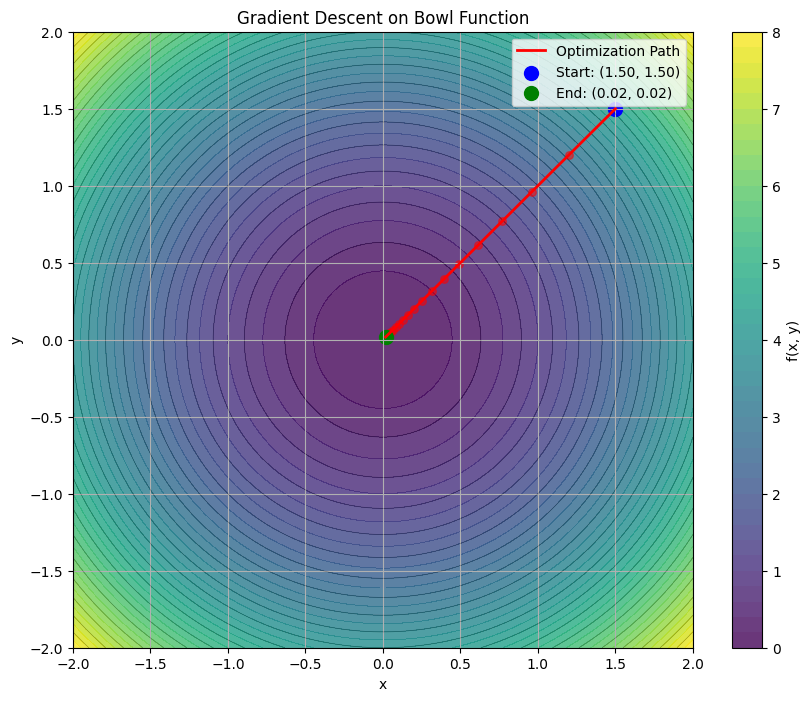

In [8]:
# Visualize the optimization path on the contour plot
plot_contour_with_path(bowl_function, history, -2, 2, -2, 2, 
                      title="Gradient Descent on Bowl Function")

### 3.1 A More Challenging 2D Function

Let's try a more complex function with multiple local minima to demonstrate some challenges in optimization.

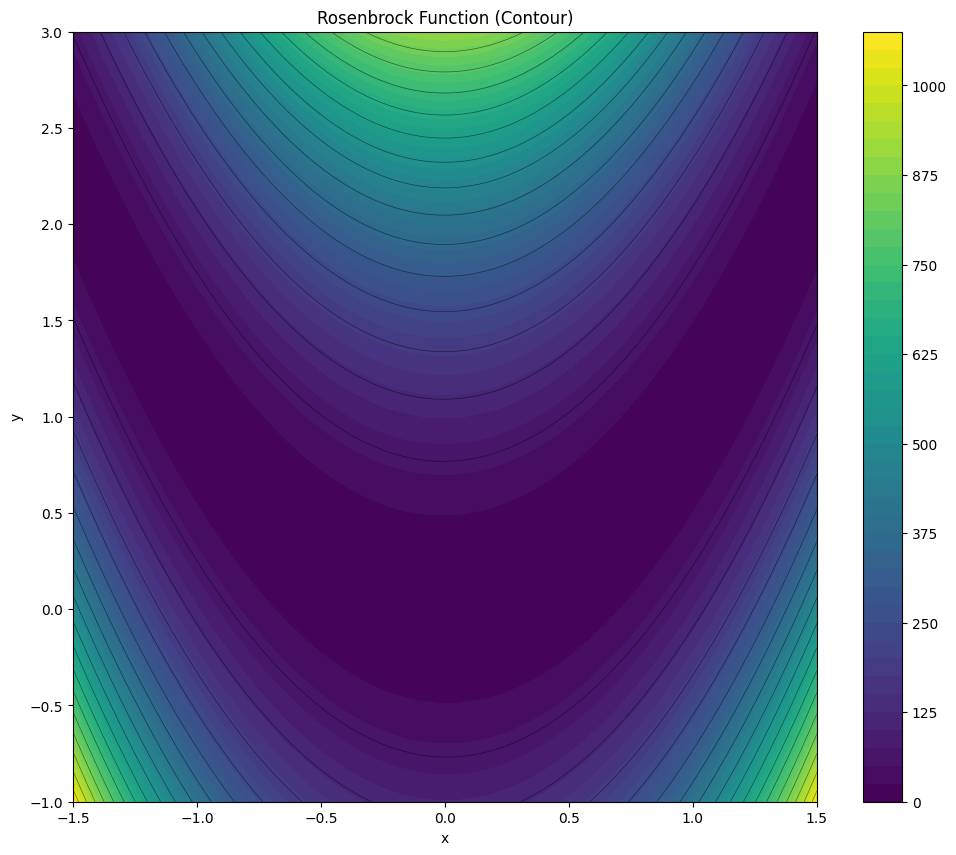

In [9]:
# Define a complex 2D function with multiple local minima
def complex_function(x):
    return (1 - x[0])**2 + 100*(x[1] - x[0]**2)**2  # Rosenbrock function

# Gradient of the complex function
def complex_gradient(x):
    dx = -2*(1 - x[0]) - 400*x[0]*(x[1] - x[0]**2)
    dy = 200*(x[1] - x[0]**2)
    return np.array([dx, dy])

# Visualize the function
plot_function_2d(complex_function, -1.5, 1.5, -1, 3, plot_type='contour',
                title="Rosenbrock Function (Contour)")

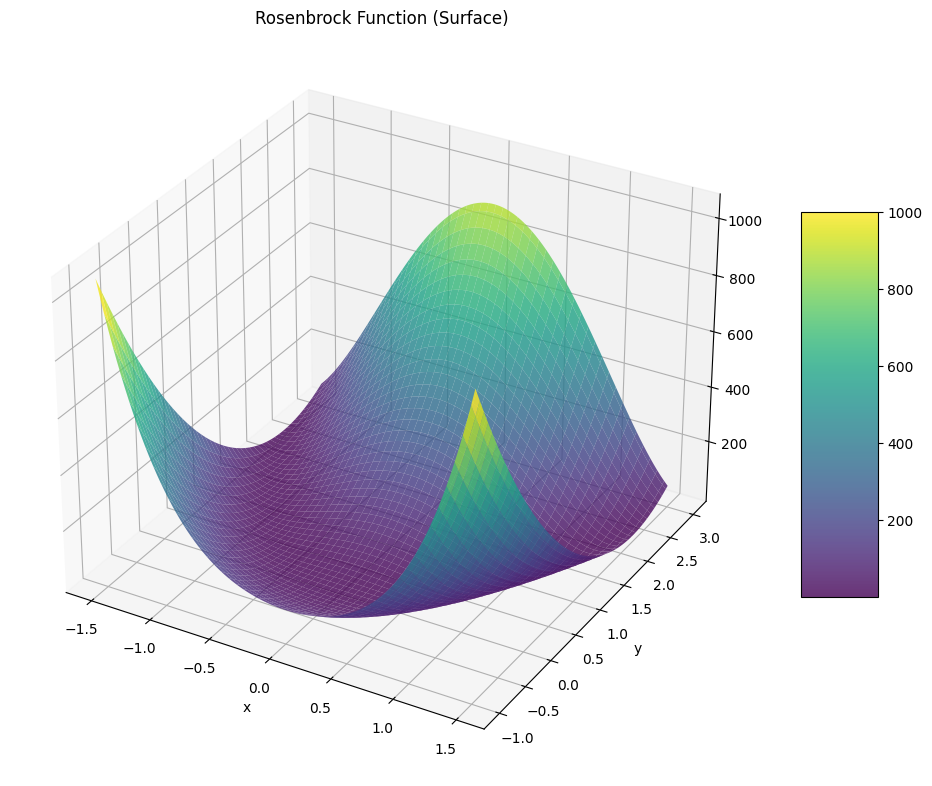

In [10]:
# Let's also see a 3D view
plot_function_2d(complex_function, -1.5, 1.5, -1, 3, plot_type='surface',
                title="Rosenbrock Function (Surface)")

In [11]:
# Run gradient descent on the complex function
x0 = np.array([-1.0, 1.0])
result, history = gradient_descent(complex_function, complex_gradient, x0, 
                                  learning_rate=0.001, max_iter=500)

print("Starting point:", x0)
print("Result after optimization:", result)
print("Function value at result:", complex_function(result))
print("Known global minimum at (1,1) with value:", complex_function(np.array([1.0, 1.0])))
print("Number of iterations:", len(history))

Starting point: [-1.  1.]
Result after optimization: [-0.44650398  0.20657452]
Function value at result: 2.0975703354208024
Known global minimum at (1,1) with value: 0.0
Number of iterations: 501


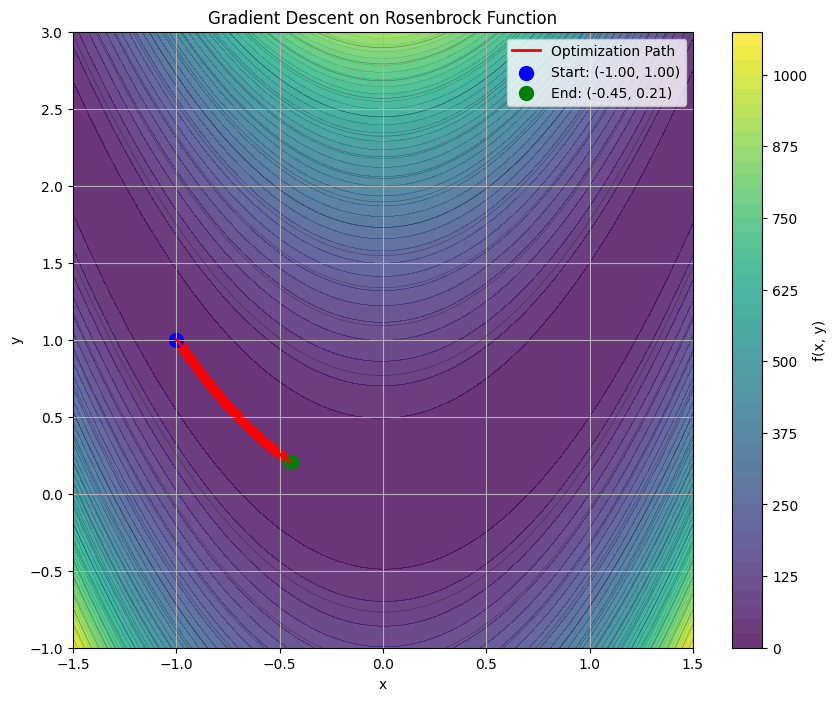

In [12]:
# Visualize the optimization path
plot_contour_with_path(complex_function, history, -1.5, 1.5, -1, 3,
                      title="Gradient Descent on Rosenbrock Function")

**Observations:**

- The Rosenbrock function has a curved narrow valley which makes optimization difficult
- Standard gradient descent requires many iterations and a small learning rate to navigate this valley
- It may struggle to reach the exact global minimum at (1,1)

## 4. Improved Optimization Algorithms

Basic gradient descent has limitations, particularly for complex loss landscapes. Several improved algorithms have been developed to address these issues. Let's explore some of them.

### 4.1 Gradient Descent with Momentum

Momentum adds a velocity term that helps gradient descent navigate ravines and valleys more effectively. The update rules are:

$$v_{t+1} = \beta v_t + (1 - \beta) \nabla f(x_t)$$
$$x_{t+1} = x_t - \alpha v_{t+1}$$

where $\beta$ is the momentum coefficient (typically 0.9).

<Figure size 1000x800 with 0 Axes>

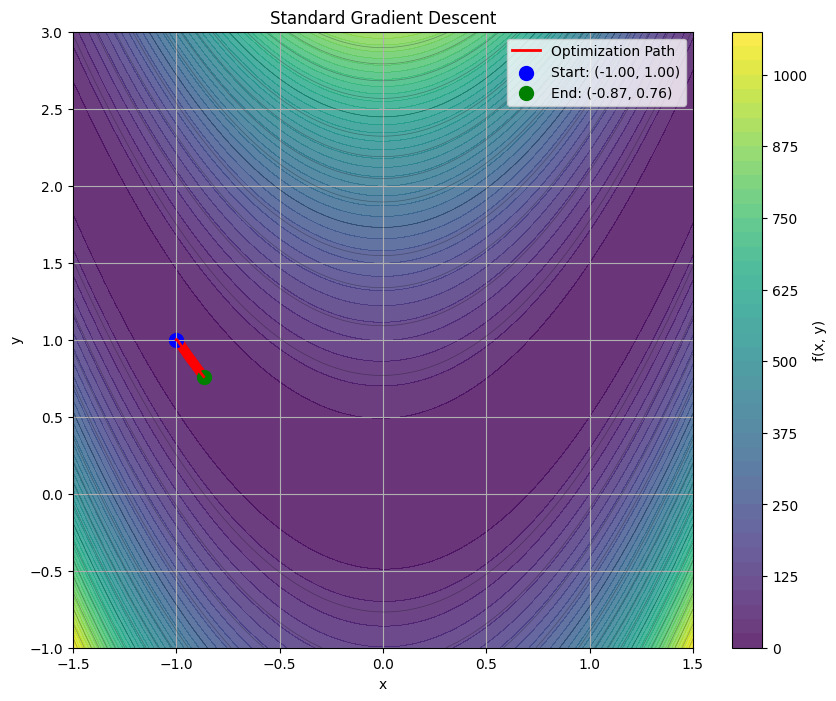

<Figure size 1000x800 with 0 Axes>

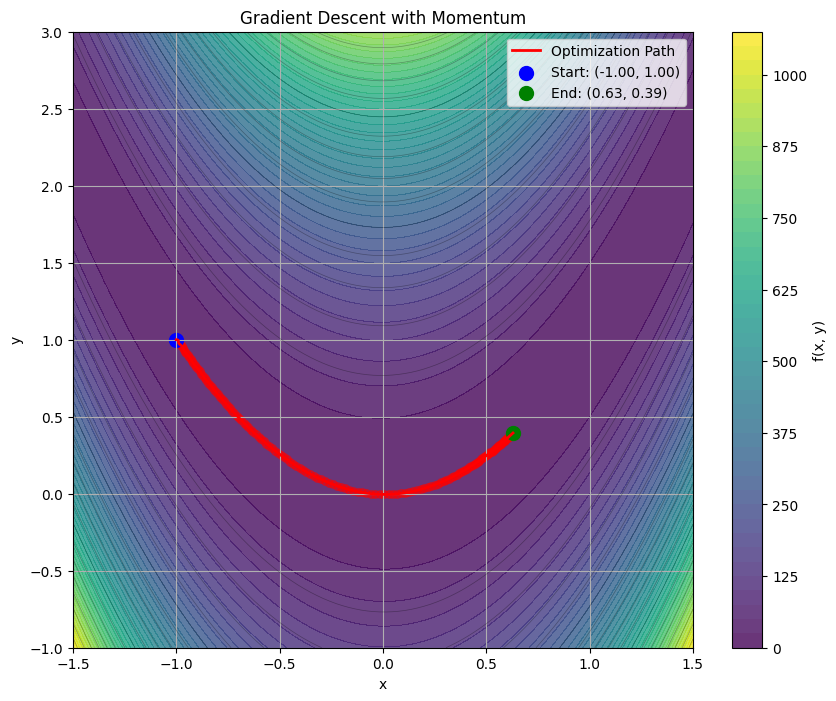

In [13]:
# Compare standard gradient descent and momentum
x0 = np.array([-1.0, 1.0])

# Run standard gradient descent
result_sgd, history_sgd = gradient_descent(
    complex_function, complex_gradient, x0.copy(), learning_rate=0.001, max_iter=150
)

# Run gradient descent with momentum
result_momentum, history_momentum = gradient_descent_with_momentum(
    complex_function, complex_gradient, x0.copy(), learning_rate=0.001, momentum=0.9, max_iter=150
)

# Visualize both paths in separate figures for clarity
plt.figure(figsize=(10, 8))
plot_contour_with_path(complex_function, history_sgd, -1.5, 1.5, -1, 3,
                      title="Standard Gradient Descent")
plt.show()

plt.figure(figsize=(10, 8))
plot_contour_with_path(complex_function, history_momentum, -1.5, 1.5, -1, 3,
                      title="Gradient Descent with Momentum")
plt.show()

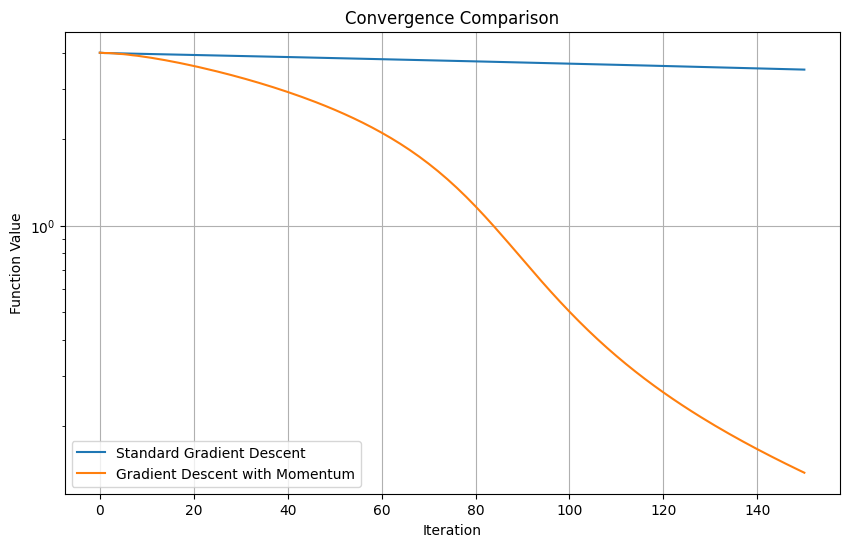

In [14]:
# Compare function values during optimization
plt.figure(figsize=(10, 6))

sgd_values = [complex_function(x) for x in history_sgd]
momentum_values = [complex_function(x) for x in history_momentum]

plt.plot(sgd_values, label="Standard Gradient Descent")
plt.plot(momentum_values, label="Gradient Descent with Momentum")
plt.xlabel("Iteration")
plt.ylabel("Function Value")
plt.title("Convergence Comparison")
plt.legend()
plt.yscale('log')
plt.grid(True)
plt.show()

### 4.2 Adaptive Learning Rate Methods

Let's explore more advanced optimization methods that adapt the learning rate for each parameter:

In [15]:
# Let's compare different optimization algorithms on the Rosenbrock function
x0 = np.array([-1.0, 1.0])
max_iter = 200

# Record function values for each algorithm
results = {}
histories = {}
function_values = {}

# Standard Gradient Descent
results["SGD"], histories["SGD"] = gradient_descent(
    complex_function, complex_gradient, x0.copy(), learning_rate=0.001, max_iter=max_iter
)
function_values["SGD"] = [complex_function(x) for x in histories["SGD"]]

# Gradient Descent with Momentum
results["Momentum"], histories["Momentum"] = gradient_descent_with_momentum(
    complex_function, complex_gradient, x0.copy(), learning_rate=0.001, momentum=0.9, max_iter=max_iter
)
function_values["Momentum"] = [complex_function(x) for x in histories["Momentum"]]

# Adagrad
results["Adagrad"], histories["Adagrad"] = adagrad(
    complex_function, complex_gradient, x0.copy(), learning_rate=0.1, max_iter=max_iter
)
function_values["Adagrad"] = [complex_function(x) for x in histories["Adagrad"]]

# RMSprop
results["RMSprop"], histories["RMSprop"] = rmsprop(
    complex_function, complex_gradient, x0.copy(), learning_rate=0.01, max_iter=max_iter
)
function_values["RMSprop"] = [complex_function(x) for x in histories["RMSprop"]]

# Adam
results["Adam"], histories["Adam"] = adam(
    complex_function, complex_gradient, x0.copy(), learning_rate=0.01, max_iter=max_iter
)
function_values["Adam"] = [complex_function(x) for x in histories["Adam"]]

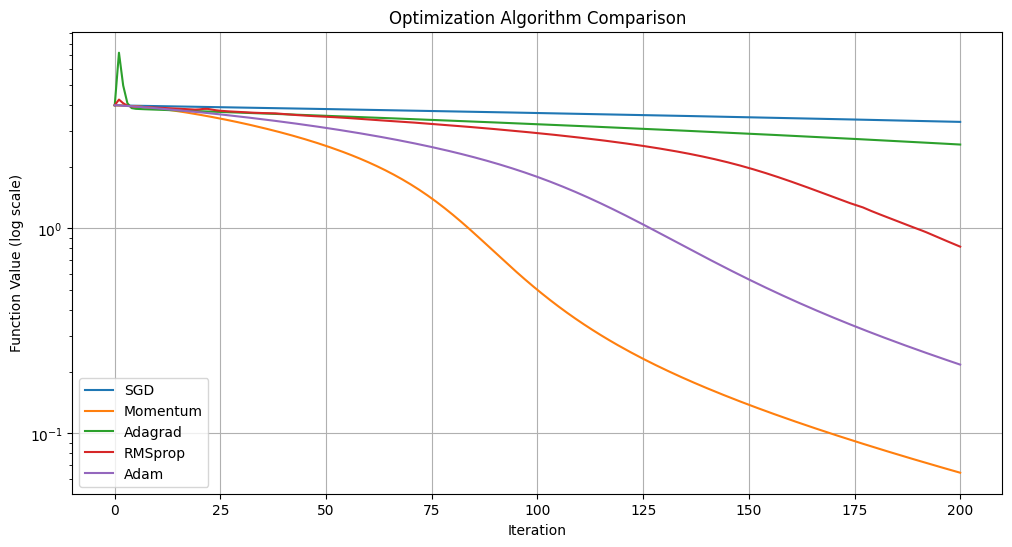

In [16]:
# Plot convergence comparison
plt.figure(figsize=(12, 6))

for name, values in function_values.items():
    plt.plot(values, label=name)

plt.xlabel("Iteration")
plt.ylabel("Function Value (log scale)")
plt.title("Optimization Algorithm Comparison")
plt.legend()
plt.grid(True)
plt.yscale('log')
plt.show()

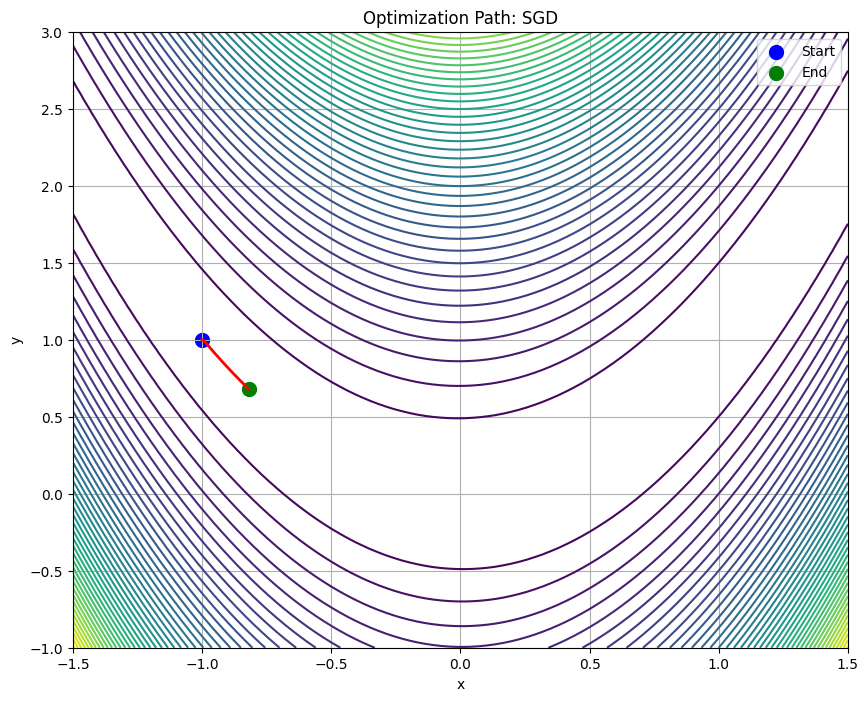

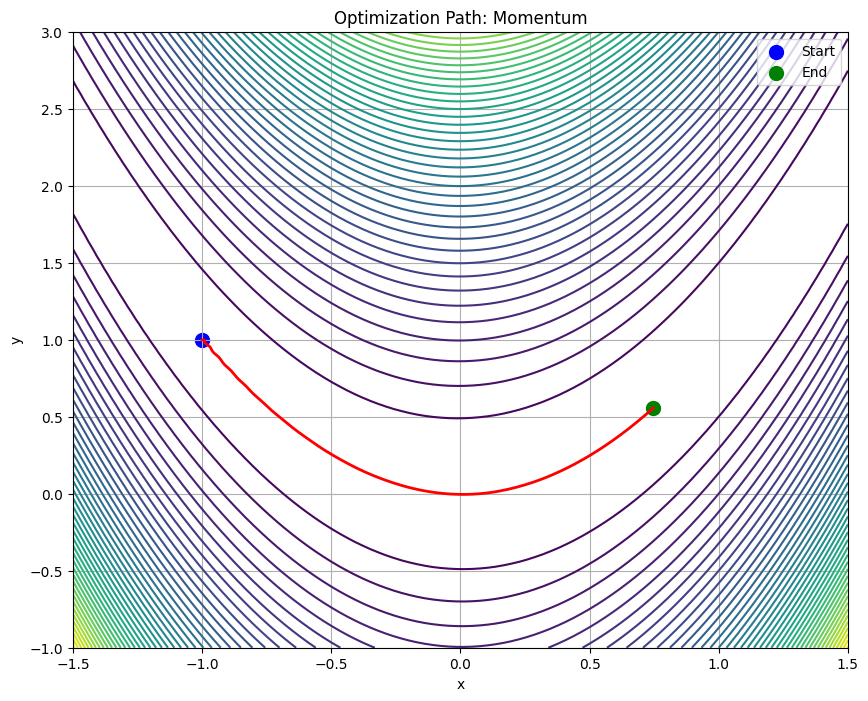

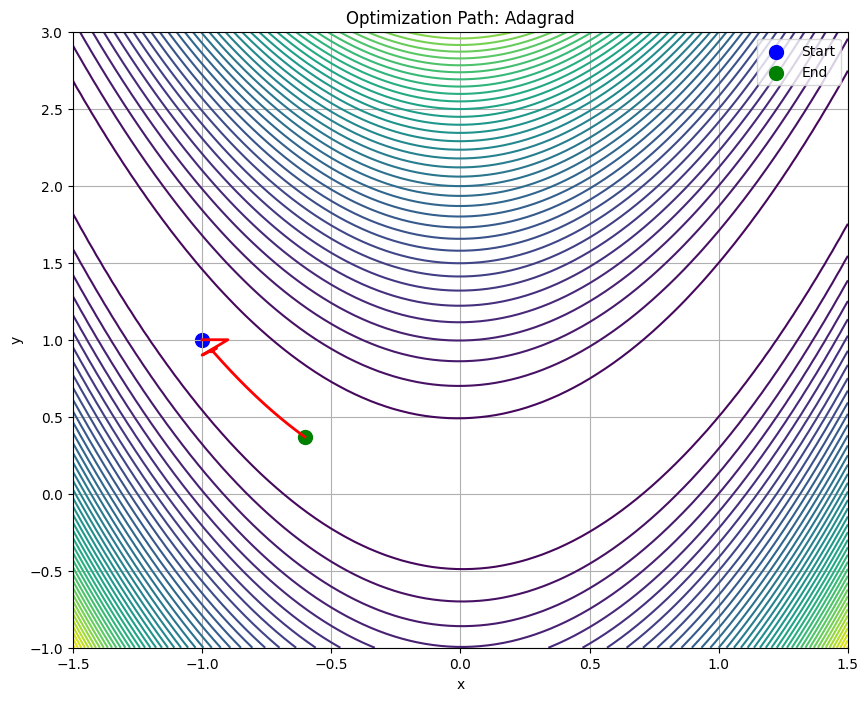

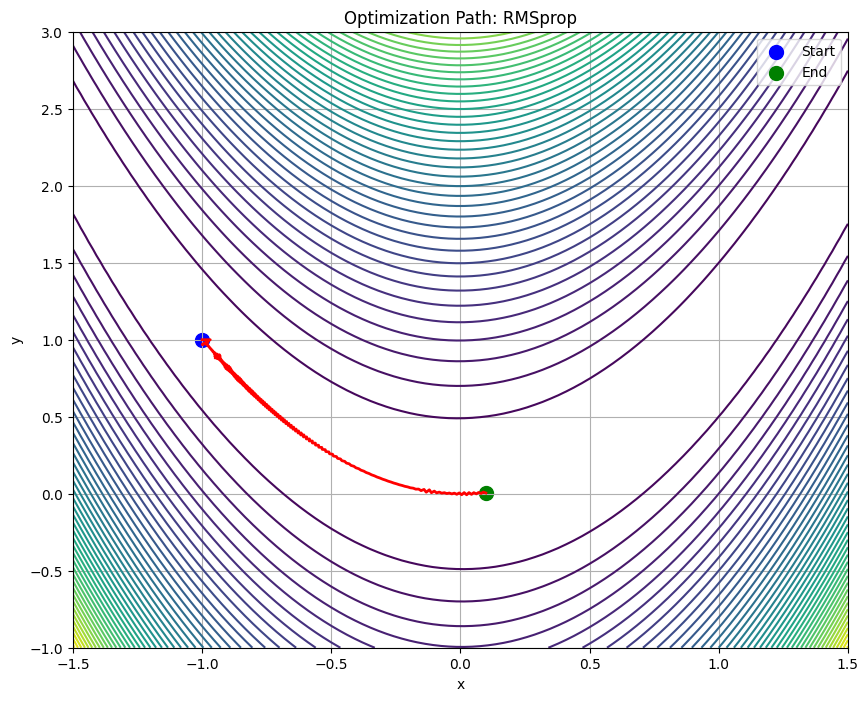

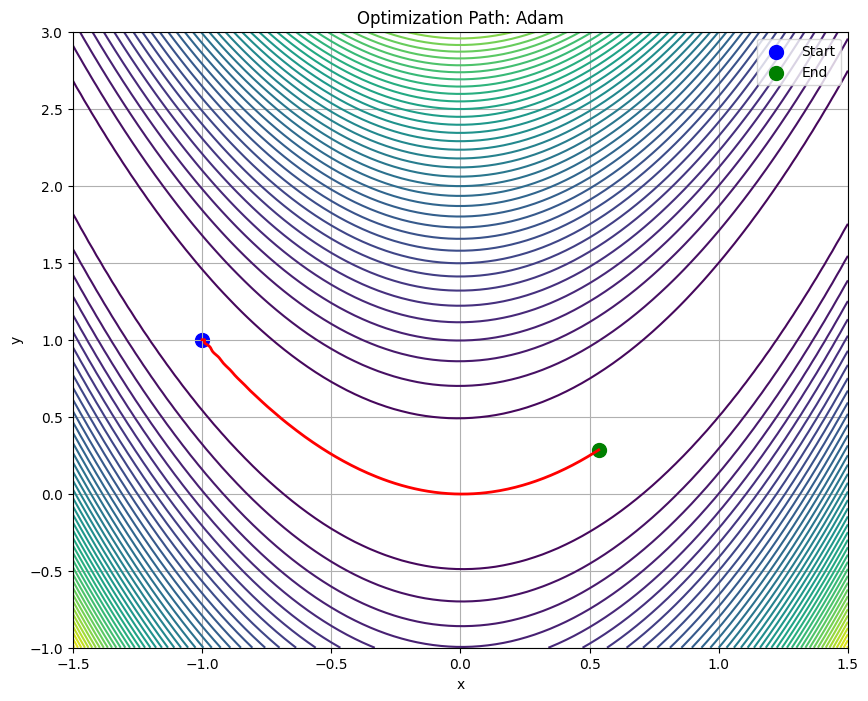

In [17]:
# Visualize the optimization paths for each algorithm individually
for name, history in histories.items():
    plt.figure(figsize=(10, 8))
    
    # Plot contours
    x = np.linspace(-1.5, 1.5, 100)
    y = np.linspace(-1, 3, 100)
    X, Y = np.meshgrid(x, y)
    Z = np.zeros_like(X)
    for i_x in range(100):
        for i_y in range(100):
            Z[i_y, i_x] = complex_function(np.array([X[i_y, i_x], Y[i_y, i_x]]))
    
    plt.contour(X, Y, Z, 50, cmap='viridis')
    plt.plot(history[:, 0], history[:, 1], 'r-', linewidth=2)
    plt.scatter(history[0, 0], history[0, 1], c='blue', s=100, label='Start')
    plt.scatter(history[-1, 0], history[-1, 1], c='green', s=100, label='End')
    plt.title(f"Optimization Path: {name}")
    plt.xlabel('x')
    plt.ylabel('y')
    plt.grid(True)
    plt.legend()
    plt.show()

**Observations:**

1. **SGD (Standard Gradient Descent)**: Simple but slow, especially in ravines or saddle points

2. **Momentum**: Accelerates convergence and helps navigate ravines better than SGD

3. **Adagrad**: Adapts learning rates per parameter, but can over-decrease rates on frequently updated parameters

4. **RMSprop**: Improves on Adagrad by using a moving average of squared gradients

5. **Adam**: Combines momentum and adaptive learning rates, often performing the best in practice

## 5. Application: Curve Fitting with Gradient Descent

Now let's apply our optimization knowledge to a practical problem: fitting a curve to data points using gradient descent.

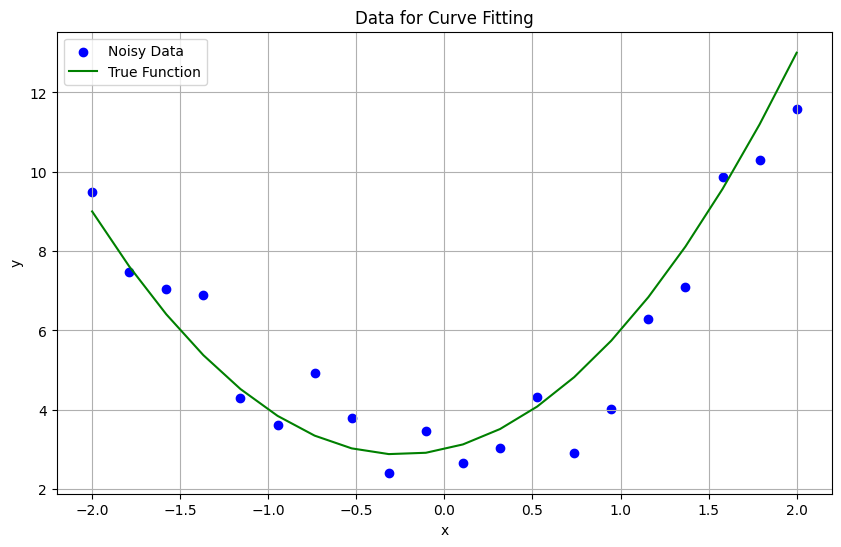

In [18]:
# Generate some noisy data points from a known function
def true_function(x, a=2, b=1, c=3):
    """The true underlying function: a*x^2 + b*x + c"""
    return a * x**2 + b * x + c

# Generate noisy data
np.random.seed(42)  # For reproducibility
x_data = np.linspace(-2, 2, 20)
y_data = true_function(x_data) + np.random.normal(0, 1, size=x_data.shape)

# Plot the data
plt.figure(figsize=(10, 6))
plt.scatter(x_data, y_data, color='blue', label='Noisy Data')
plt.plot(x_data, true_function(x_data), 'g-', label='True Function')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Data for Curve Fitting')
plt.legend()
plt.grid(True)
plt.show()

In [19]:
# Define the model and loss function
def model(x, params):
    """Model function: params[0]*x^2 + params[1]*x + params[2]"""
    a, b, c = params
    return a * x**2 + b * x + c

def mse_loss(params):
    """Mean squared error loss function"""
    predictions = model(x_data, params)
    return np.mean((predictions - y_data)**2)

def mse_gradient(params):
    """Gradient of the MSE loss with respect to model parameters"""
    predictions = model(x_data, params)
    errors = predictions - y_data
    n = len(x_data)
    
    # Partial derivatives
    grad_a = (2/n) * np.sum(errors * x_data**2)
    grad_b = (2/n) * np.sum(errors * x_data)
    grad_c = (2/n) * np.sum(errors)
    
    return np.array([grad_a, grad_b, grad_c])

In [20]:
# Initial guess for parameters [a, b, c]
initial_params = np.array([0.5, 0.5, 0.5])

# Use Adam optimizer for curve fitting
optimized_params, param_history = adam(
    mse_loss, mse_gradient, initial_params, learning_rate=0.1, max_iter=200
)

print("Initial parameters:", initial_params)
print("Optimized parameters:", optimized_params)
print("True parameters: [2, 1, 3]")
print("Final loss:", mse_loss(optimized_params))

Initial parameters: [0.5 0.5 0.5]
Optimized parameters: [1.95841113 0.52706887 2.89020228]
True parameters: [2, 1, 3]
Final loss: 0.5429924799154932


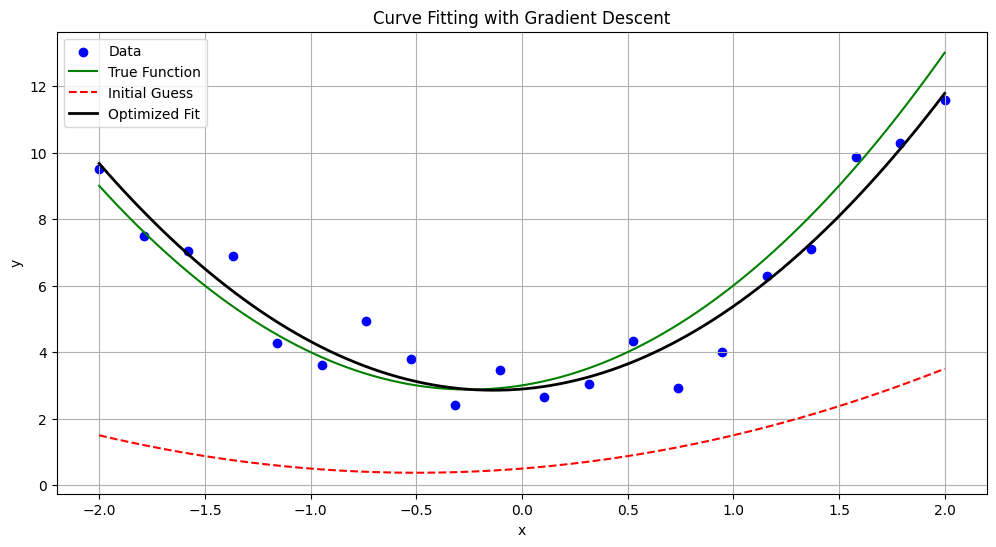

In [21]:
# Plot the fitting process
plt.figure(figsize=(12, 6))

# Plot the data points
plt.scatter(x_data, y_data, color='blue', label='Data')

# Plot the true function
x_fine = np.linspace(-2, 2, 100)
plt.plot(x_fine, true_function(x_fine), 'g-', label='True Function')

# Plot the initial guess
plt.plot(x_fine, model(x_fine, initial_params), 'r--', label='Initial Guess')

# Plot the final fit
plt.plot(x_fine, model(x_fine, optimized_params), 'k-', linewidth=2, label='Optimized Fit')

plt.xlabel('x')
plt.ylabel('y')
plt.title('Curve Fitting with Gradient Descent')
plt.legend()
plt.grid(True)
plt.show()

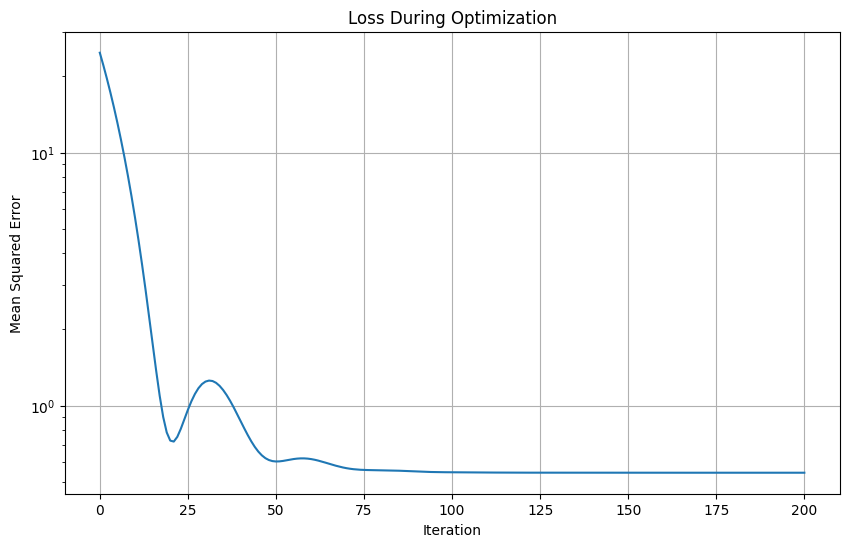

In [22]:
# Visualize the loss during optimization
loss_history = [mse_loss(params) for params in param_history]

plt.figure(figsize=(10, 6))
plt.plot(loss_history)
plt.xlabel('Iteration')
plt.ylabel('Mean Squared Error')
plt.title('Loss During Optimization')
plt.grid(True)
plt.yscale('log')
plt.show()

## 6. Gradient Descent with Numerical Differentiation

So far, we've used analytical gradients for our optimization. However, in many real-world scenarios, we don't have access to the analytical gradient. Let's see how we can use our numerical differentiation functions from the previous notebook to perform gradient descent.

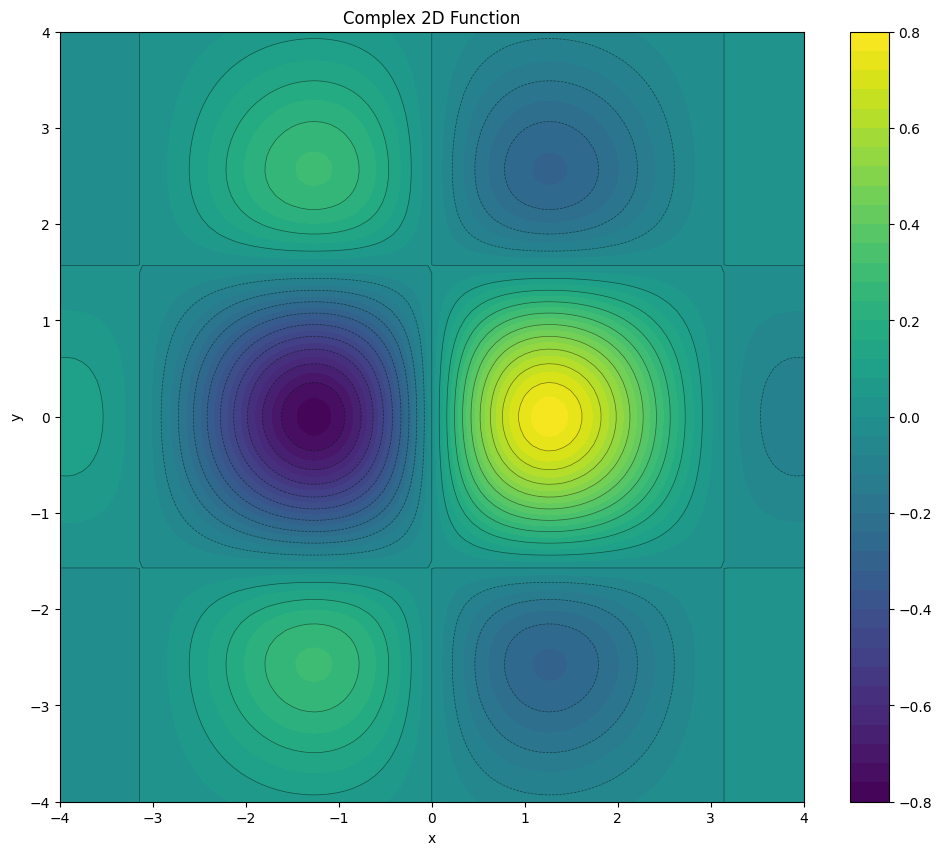

In [23]:
# Import the numerical gradient function
from phase0.calculus.differentiation import gradient as numerical_gradient

# Define a function with a complicated analytical gradient
def complex_2d_function(x):
    return np.sin(x[0]) * np.cos(x[1]) * np.exp(-(x[0]**2 + x[1]**2)/8)

# Visualize this function
plot_function_2d(complex_2d_function, -4, 4, -4, 4, plot_type='contour',
                title="Complex 2D Function")

In [24]:
# Let's maximize this function (find the maximum)
# To do this with our minimization methods, we'll negate the function
def neg_complex_2d_function(x):
    return -complex_2d_function(x)

# Gradient using numerical differentiation
def numerical_grad_wrapper(x):
    return numerical_gradient(neg_complex_2d_function, x)

# Starting point
x0 = np.array([-2.0, 2.0])

# Run optimization
result, history = adam(neg_complex_2d_function, numerical_grad_wrapper, x0, 
                       learning_rate=0.2, max_iter=100)

print("Starting point:", x0)
print("Found maximum at:", result)
print("Function value at maximum:", complex_2d_function(result))

Starting point: [-2.  2.]
Found maximum at: [-1.26361007  2.57281049]
Function value at maximum: 0.2875770894881703


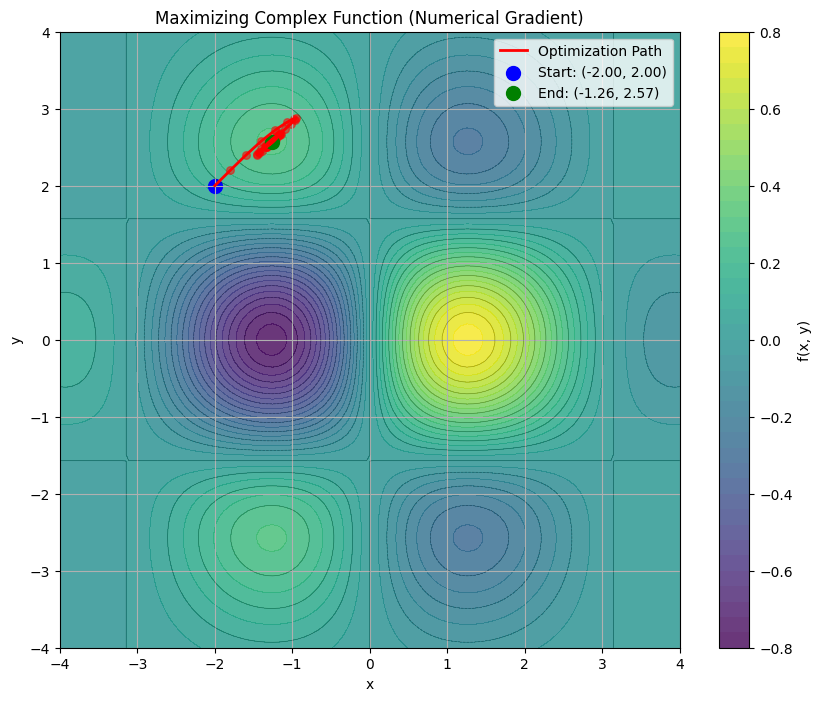

In [25]:
# Visualize the optimization path
# We need to negate the function for the contour plot to show maxima correctly
def neg_for_contour(x):
    return -neg_complex_2d_function(x)

plot_contour_with_path(neg_for_contour, history, -4, 4, -4, 4,
                      title="Maximizing Complex Function (Numerical Gradient)")

## 7. Challenges in Optimization

Gradient-based optimization methods face several challenges in real-world applications. Let's explore some of them:

### 7.1 Local Minima vs. Global Minima

Let's create a function with multiple local minima:

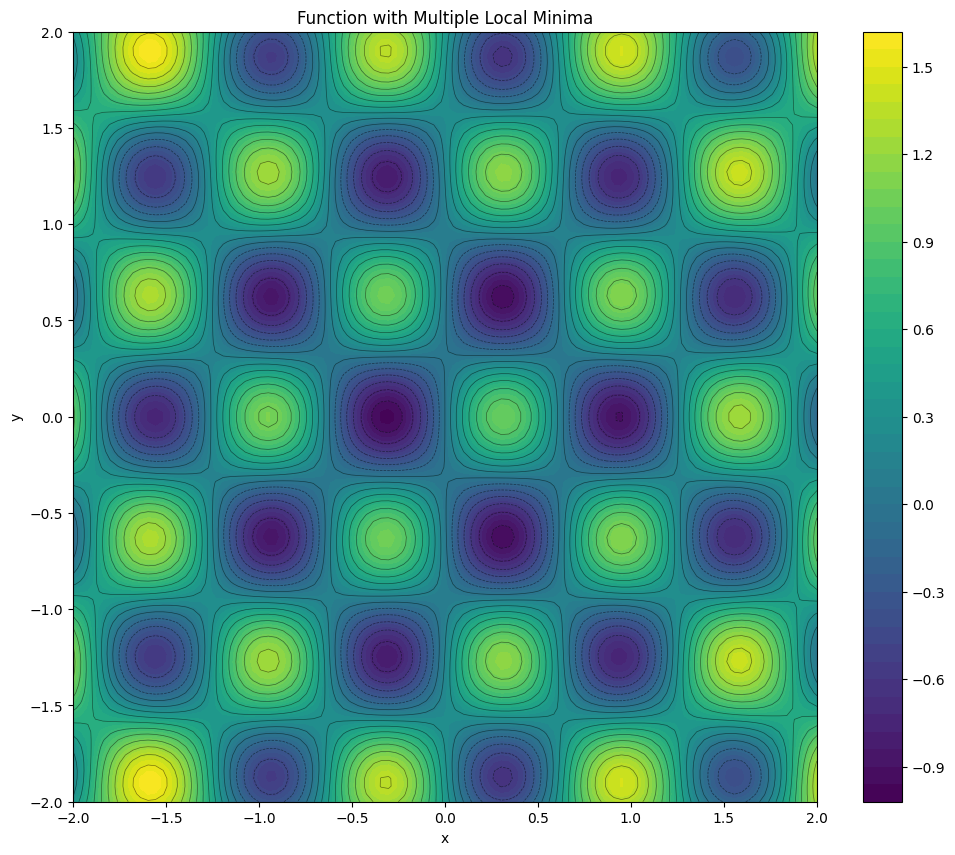

In [26]:
# Define a function with multiple local minima
def multimodal_function(x):
    return np.sin(5 * x[0]) * np.cos(5 * x[1]) + 0.1 * (x[0]**2 + x[1]**2)

# Visualize the function
plot_function_2d(multimodal_function, -2, 2, -2, 2, plot_type='contour',
                title="Function with Multiple Local Minima")

In [27]:
# Try optimization from different starting points
starting_points = [
    np.array([1.0, 1.0]),
    np.array([-1.0, -1.0]),
    np.array([0.5, -0.5]),
    np.array([-0.5, 0.5])
]

results = []
histories = []

for x0 in starting_points:
    # Use numerical gradient for flexibility
    result, history = gradient_descent(
        multimodal_function, lambda x: numerical_gradient(multimodal_function, x),
        x0, learning_rate=0.05, max_iter=100, tol=1e-8
    )
    results.append(result)
    histories.append(history)
    
    print(f"Starting at {x0}, converged to {result} with value {multimodal_function(result):.6f}")

Starting at [1. 1.], converged to [0.93498181 1.24664768] with value -0.755219
Starting at [-1. -1.], converged to [-0.93499877 -0.6233329 ] with value -0.872714
Starting at [ 0.5 -0.5], converged to [ 0.31166011 -0.62333598] with value -0.951044
Starting at [-0.5  0.5], converged to [-0.93499877  0.6233229 ] with value -0.872714


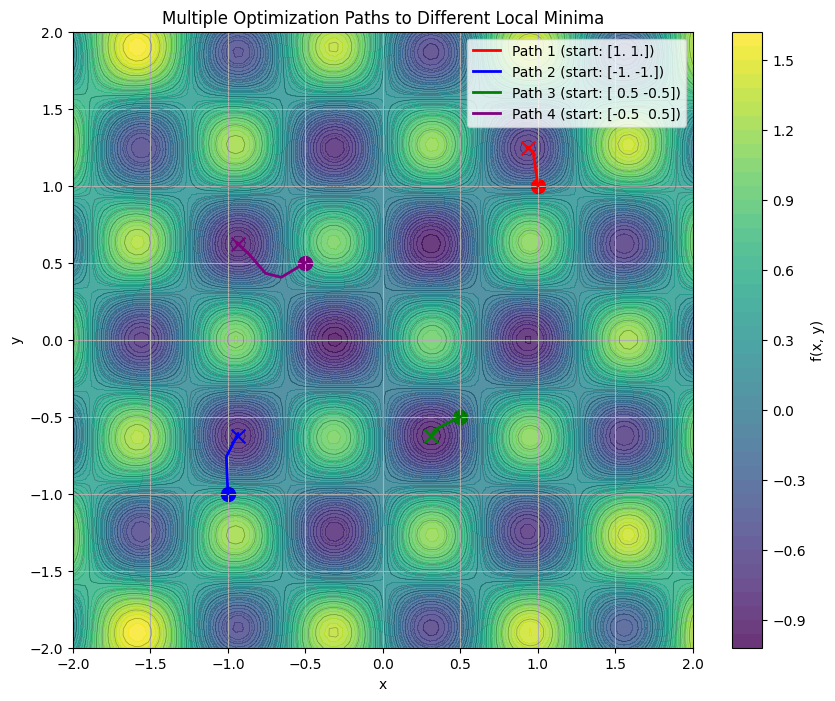

In [28]:
# Visualize all optimization paths
plt.figure(figsize=(10, 8))

# Create contour plot
x = np.linspace(-2, 2, 100)
y = np.linspace(-2, 2, 100)
X, Y = np.meshgrid(x, y)
Z = np.zeros_like(X)
for i in range(100):
    for j in range(100):
        Z[i, j] = multimodal_function(np.array([X[i, j], Y[i, j]]))

plt.contourf(X, Y, Z, 50, cmap='viridis', alpha=0.8)
plt.colorbar(label='f(x, y)')
plt.contour(X, Y, Z, 20, colors='black', linewidths=0.5, alpha=0.3)

# Plot paths with different colors
colors = ['red', 'blue', 'green', 'purple']
for i, (history, color) in enumerate(zip(histories, colors)):
    plt.plot(history[:, 0], history[:, 1], color=color, linewidth=2, 
             label=f"Path {i+1} (start: {starting_points[i]})")
    plt.scatter(history[0, 0], history[0, 1], color=color, s=100)
    plt.scatter(history[-1, 0], history[-1, 1], color=color, s=100, marker='x')

plt.title("Multiple Optimization Paths to Different Local Minima")
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid(True)
plt.show()

**Observations:**

- Different starting points lead to different local minima
- Gradient descent can only find the nearest local minimum from the starting point
- For complex problems, we often need multiple runs from different starting points or more advanced global optimization techniques

## 8. Conclusion

In this notebook, we've explored gradient descent and various optimization techniques. Key takeaways include:

1. **Gradient Descent Fundamentals**:
   - Uses gradients to iteratively move toward function minima
   - Learning rate is a critical hyperparameter
   - Works in multiple dimensions using partial derivatives

2. **Advanced Optimizers**:
   - Momentum helps navigate ravines more efficiently
   - Adaptive methods (Adagrad, RMSprop, Adam) adjust learning rates per parameter
   - Different optimizers excel in different scenarios

3. **Practical Applications**:
   - Curve fitting and parameter estimation
   - Machine learning model training
   - Numerical optimization when analytical solutions aren't available

4. **Optimization Challenges**:
   - Local vs. global minima
   - Sensitivity to initial conditions
   - Need for problem-specific optimization strategies

These optimization techniques form the foundation of neural network training algorithms and are essential for understanding how deep learning models learn from data.